<a href="https://colab.research.google.com/github/xoxoreyniel/DSC1107/blob/main/DSC1107_FA3_Awit%2C_JT%3B_Deloyola%2C_JR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[1] 30 54

'data.frame':	30 obs. of  54 variables:
 $ payroll       : num  1.12 1.38 1.16 1.97 1.46 ...
 $ avgwin        : num  0.49 0.553 0.454 0.549 0.474 ...
 $ Team.name.2014: Factor w/ 30 levels "Arizona Diamondbacks",..: 1 2 3 4 5 6 7 8 9 10 ...
 $ p1998         : num  31.6 61.7 71.9 59.5 49.8 ...
 $ p1999         : num  70.5 74.9 72.2 71.7 42.1 ...
 $ p2000         : num  81 84.5 81.4 77.9 60.5 ...
 $ p2001         : num  81.2 91.9 72.4 109.6 64 ...
 $ p2002         : num  102.8 93.5 60.5 108.4 75.7 ...
 $ p2003         : num  80.6 106.2 73.9 99.9 79.9 ...
 $ p2004         : num  70.2 88.5 51.2 125.2 91.1 ...
 $ p2005         : num  63 85.1 74.6 121.3 87.2 ...
 $ p2006         : num  59.7 90.2 72.6 120.1 94.4 ...
 $ p2007         : num  52.1 87.3 93.6 143 99.7 ...
 $ p2008         : num  66.2 102.4 67.2 133.4 118.3 ...
 $ p2009         : num  73.6 96.7 67.1 122.7 135.1 ...
 $ p2010         : num  60.7 84.4 81.6 162.7 146.9 ...
 $ p2011         : num  53.6 87 85.3 161.4 125.5 ...
 $ p2012  

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `year = as.numeric(str_replace(year_str, "p", ""))`.
Caused by warning:
! NAs introduced by coercion”


[1] "RESULTS"
[1] "Rows in mlb_yearly: 510"


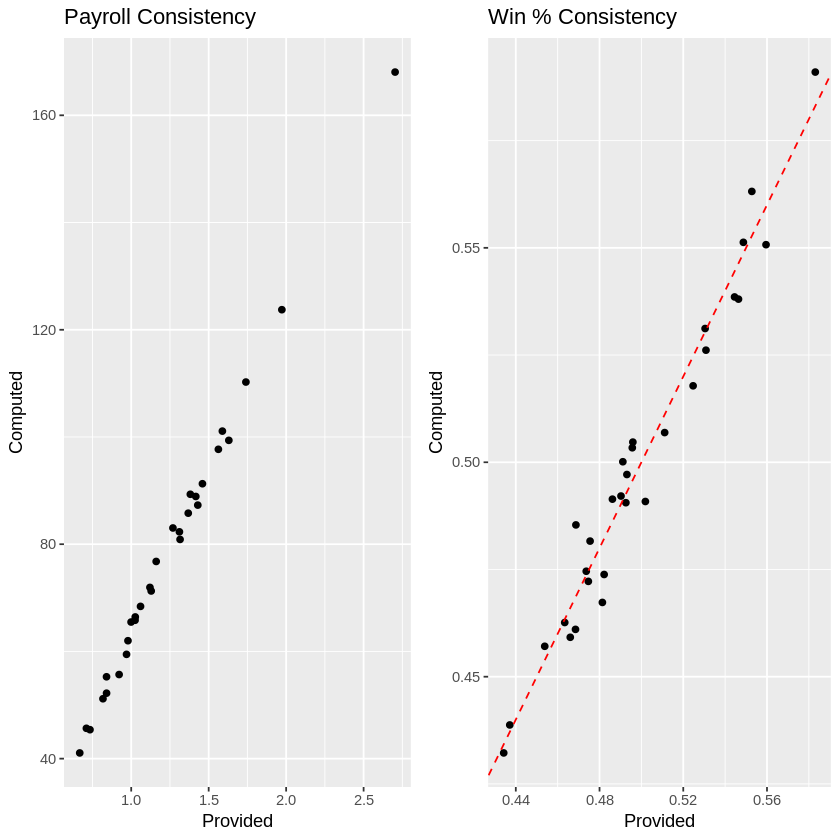


Call:
lm(formula = pct_wins_aggregate ~ payroll_aggregate, data = mlb_agg)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.039888 -0.014780 -0.001019  0.007697  0.067377 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       0.4163325  0.0149417  27.864  < 2e-16 ***
payroll_aggregate 0.0010504  0.0001815   5.787 3.25e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02588 on 28 degrees of freedom
Multiple R-squared:  0.5447,	Adjusted R-squared:  0.5284 
F-statistic: 33.49 on 1 and 28 DF,  p-value: 3.249e-06



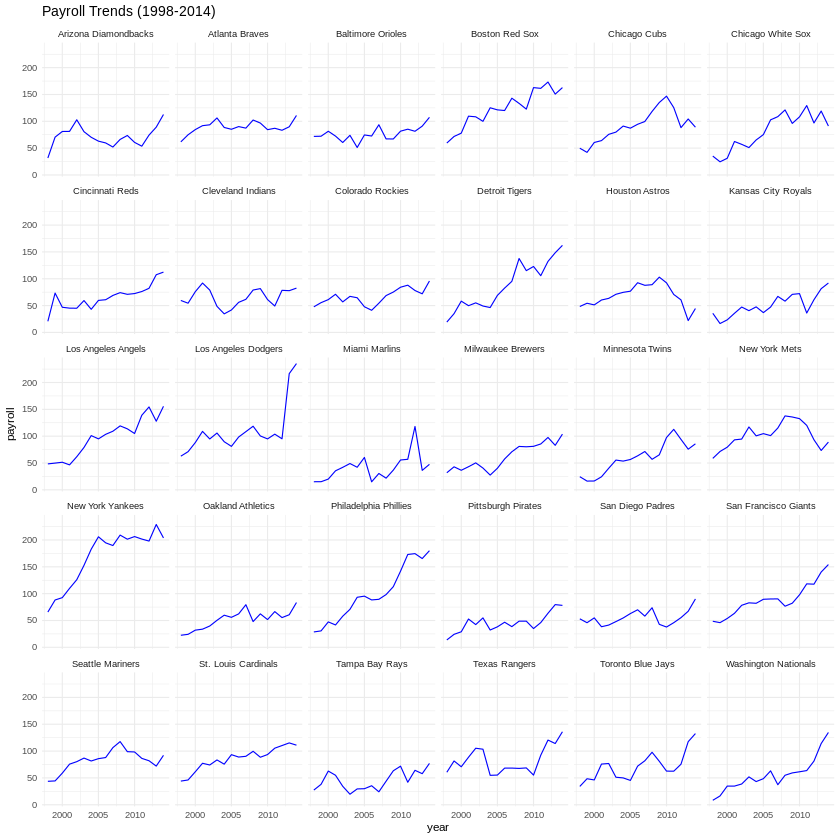

[1] "Top 3 Efficient Teams:"


team,payroll_aggregate,pct_wins_aggregate,efficiency
<fct>,<dbl>,<dbl>,<dbl>
Miami Marlins,41.06429,0.4673161,0.01138011
Oakland Athletics,52.21017,0.5385489,0.01031502
Tampa Bay Rays,45.65805,0.4610341,0.01009754


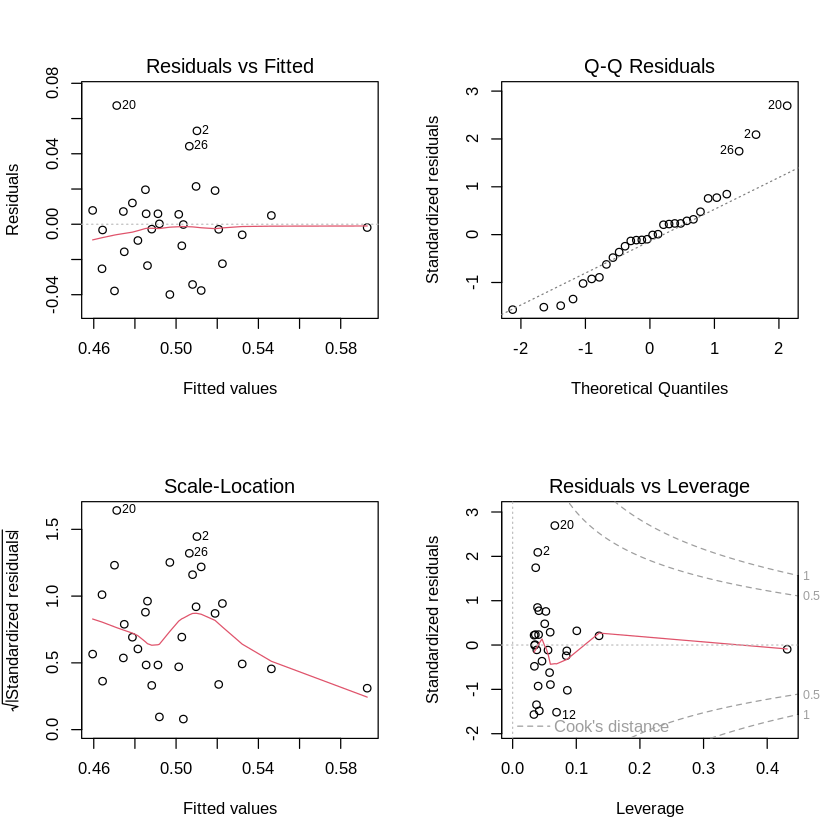

In [2]:
# ==============================================================================
# Case Study: Payroll and Wins in MLB (1998–2014)
# COMPLETE INTEGRATED SCRIPT
# ==============================================================================

# Clear environment for a fresh start
rm(list = ls())

# 1. Setup & Installations
install.packages(c("ggrepel", "cowplot", "performance", "car"),
                 repos = "http://cran.us.r-project.org", quiet = TRUE)

library(tidyverse)
library(ggrepel)
library(broom)
library(cowplot)
library(car)
library(performance)

# 2. Load and Tidy Data
# Load the data
load("/content/ml_pay.rdata")
mlb_raw <- ml_pay
dim(mlb_raw)
str(mlb_raw)

# Reshape Payroll (p1998-p2014)
mlb_payroll_long <- mlb_raw %>%
  dplyr::select(team = `Team.name.2014`, starts_with("p")) %>%
  pivot_longer(cols = starts_with("p"), names_to = "year_str", values_to = "payroll") %>%
  mutate(year = as.numeric(str_replace(year_str, "p", ""))) %>%
  filter(!is.na(year)) %>%
  dplyr::select(team, year, payroll)

# Reshape Win % (X1998.pct-X2014.pct)
pct_wins_long <- mlb_raw %>%
  dplyr::select(team = `Team.name.2014`, ends_with(".pct")) %>%
  pivot_longer(cols = ends_with(".pct"), names_to = "year_str", values_to = "pct_wins") %>%
  mutate(year = as.numeric(str_extract(year_str, "\\d{4}"))) %>%
  filter(!is.na(year)) %>%
  dplyr::select(team, year, pct_wins)

# Reshape Num Wins (X1998-X2014)
num_wins_long <- mlb_raw %>%
  dplyr::select(team = `Team.name.2014`, matches("^X\\d{4}$")) %>%
  pivot_longer(cols = matches("^X\\d{4}$"), names_to = "year_str", values_to = "num_wins") %>%
  mutate(year = as.numeric(str_extract(year_str, "\\d{4}"))) %>%
  filter(!is.na(year)) %>%
  dplyr::select(team, year, num_wins)

# Final join to create mlb_yearly (Target: 510 rows)
mlb_yearly <- mlb_payroll_long %>%
  left_join(pct_wins_long, by = c("team", "year")) %>%
  left_join(num_wins_long, by = c("team", "year"))

# Create mlb_aggregate
mlb_agg <- mlb_yearly %>%
  group_by(team) %>%
  summarize(
    payroll_aggregate = mean(payroll, na.rm = TRUE),
    pct_wins_aggregate = mean(pct_wins, na.rm = TRUE)
  )

# --- Part 2: Consistency Check ---
provided_agg <- mlb_raw %>%
  dplyr::select(team = `Team.name.2014`, provided_payroll = payroll, provided_wins = avgwin)
comp_data <- left_join(mlb_agg, provided_agg, by = "team")

p_consist1 <- ggplot(comp_data, aes(x = provided_payroll, y = payroll_aggregate)) +
  geom_point() + geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  labs(title = "Payroll Consistency", x = "Provided", y = "Computed")

p_consist2 <- ggplot(comp_data, aes(x = provided_wins, y = pct_wins_aggregate)) +
  geom_point() + geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  labs(title = "Win % Consistency", x = "Provided", y = "Computed")

# --- Part 3: EDA & Correlation ---
trend <- ggplot(mlb_yearly, aes(x = year, y = payroll)) +
  geom_line(color = "blue") + facet_wrap(~team) +
  theme_minimal(base_size = 7) + labs(title = "Payroll Trends (1998-2014)")

cor_test <- cor.test(mlb_agg$payroll_aggregate, mlb_agg$pct_wins_aggregate)

# --- Part 4: Regression & Diagnostics ---
model1 <- lm(pct_wins_aggregate ~ payroll_aggregate, data = mlb_agg)

# Outlier Analysis
cooks_d <- cooks.distance(model1)
idx <- which(cooks_d > (4/nrow(mlb_agg)))
mlb_reduced <- mlb_agg[-idx[1], ]
model_reduced <- lm(pct_wins_aggregate ~ payroll_aggregate, data = mlb_reduced)

# --- Part 5: Extensions ---
model_log <- lm(pct_wins_aggregate ~ log(payroll_aggregate), data = mlb_agg)
mlb_eff <- mlb_agg %>%
  mutate(efficiency = pct_wins_aggregate / payroll_aggregate) %>%
  arrange(desc(efficiency))

print("RESULTS")
print(paste("Rows in mlb_yearly:", nrow(mlb_yearly)))
print(plot_grid(p_consist1, p_consist2))
print(trend)
print(summary(model1))

# Diagnostics
par(mfrow = c(2, 2))
plot(model1)

print("Top 3 Efficient Teams:")
head(mlb_eff, 3)